In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from  sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Mushroom_train.csv")

In [3]:
df=df.drop(columns=["veil-type","spore-print-color","veil-color","stem-root","stem-surface"],axis=1)

In [4]:
df["gill-spacing"]=df["gill-spacing"].fillna(df["gill-spacing"].mode()[0])
df["cap-surface"]=df["cap-surface"].fillna(df["cap-surface"].mode()[0])
df["gill-attachment"]=df["gill-attachment"].fillna(df["gill-attachment"].mode()[0])
df["ring-type"]=df["ring-type"].fillna(df["ring-type"].mode()[0])

In [5]:
df1=(df.isna().sum()/len(df))*100
df1.sort_values(ascending=False)

,0
class,0.0
cap-diameter,0.0
cap-shape,0.0
cap-surface,0.0
cap-color,0.0
does-bruise-or-bleed,0.0
gill-attachment,0.0
gill-spacing,0.0
gill-color,0.0
stem-height,0.0


In [6]:
x=df.drop('class',axis=1)
y=df['class']

In [7]:
cat_col=x.select_dtypes(include=object).columns
num_col=x.select_dtypes(exclude=object).columns
print(cat_col)
print(num_col)

Index(['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',
       'gill-attachment', 'gill-spacing', 'gill-color', 'stem-color',
       'has-ring', 'ring-type', 'habitat', 'season'],
      dtype='object')
Index(['cap-diameter', 'stem-height', 'stem-width'], dtype='object')


In [8]:
num_pipeline=Pipeline(steps=[
    ("scaler",StandardScaler())
])

In [9]:
cat_pipeline=Pipeline(steps=[
    ("encoder",OneHotEncoder(drop="first",handle_unknown="ignore"))
])

In [10]:
preprocessor=ColumnTransformer([
    ("num",num_pipeline,num_col),
    ("cat",cat_pipeline,cat_col)
])

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=20,test_size=.20)

In [12]:
from collections import Counter
print("Before ros",Counter(y_train)) #before ros
from imblearn.over_sampling import RandomOverSampler
ros=RandomOverSampler()
x_train_ros,y_train_ros=ros.fit_resample(x_train,y_train)
print("After ros",Counter(y_train_ros)) #after ros

Before ros Counter({'p': 27019, 'e': 21820})
After ros Counter({'p': 27019, 'e': 27019})


In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_ros = le.fit_transform(y_train_ros)
y_test = le.transform(y_test)

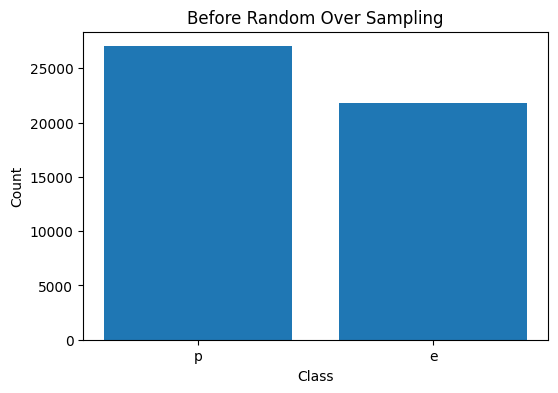

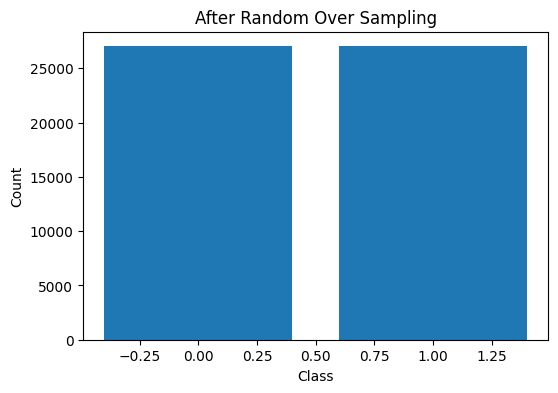

In [14]:
from collections import Counter
import matplotlib.pyplot as plt

# Before ROS
plt.figure(figsize=(6,4))
plt.bar(Counter(y_train).keys(), Counter(y_train).values())
plt.title("Before Random Over Sampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# After ROS
plt.figure(figsize=(6,4))
plt.bar(Counter(y_train_ros).keys(), Counter(y_train_ros).values())
plt.title("After Random Over Sampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


**Decision Tree**

In [15]:
dt_pipe=Pipeline([
    ('preprocessor',preprocessor),
    ('model',DecisionTreeClassifier(random_state=40))
])
dt_param={
    # 'model__max_depth':[None,10],
    # 'model__min_samples_split':[10,25],
    # 'model__min_samples_leaf':[5,15],
    'model__max_leaf_nodes':[30,45]
}
dt_grid=GridSearchCV(
    dt_pipe,
    dt_param,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [16]:
dt_grid.fit(x_train_ros,y_train_ros)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['cap-diameter', 'stem-height', 'stem-width'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',
       'gill-attachment', 'gill-spacing', 'gill-color', 'stem-color',
       'has-ring', 'ring-type', 'habitat', 'season'],
      dtype='object'))])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=40))]),
             n_jobs=-1, param_grid={'model__max_leaf_nodes': [30, 45]},
             scoring='f1')

In [17]:
best_dt=dt_grid.best_estimator_
print("Best Decision Tree Prams: ",dt_grid.best_params_)

Best Decision Tree Prams:  {'model__max_leaf_nodes': 45}


In [18]:
#predict
y_pred_train_dt=best_dt.predict(x_train_ros)
y_pred_test_dt=best_dt.predict(x_test)
#score
y_train_score_dt=best_dt.score(x_train_ros,y_train_ros)
y_test_score_dt=best_dt.score(x_test,y_test)
#output
print("y train score",y_train_score_dt*100)
print("y test score",y_test_score_dt*100)

#cross validation
cross_val_score_train=cross_val_score(best_dt,x_train_ros,y_train_ros,cv=10,scoring="r2").mean()
cross_val_score_test=cross_val_score(best_dt,x_test,y_test,cv=10,scoring="r2").mean()
print("Train cross_val_score: ",cross_val_score_train)
print("Test cross_val_score: ",cross_val_score_test)
#classification report
classification_report_train_dt=classification_report(y_train_ros,y_pred_train_dt)
print("classification_report_train_dt: \n",classification_report_train_dt)
classification_report_test_dt=classification_report(y_test,y_pred_test_dt)
print("classification_report_test_dt: \n",classification_report_test_dt)
#confusion matrix
cm=confusion_matrix(y_test,y_pred_test_dt)
print("confusion matrix",cm)

y train score 90.35123431659203
y test score 90.0982800982801
Train cross_val_score:  0.6090900072374983
Test cross_val_score:  0.6170929538956984
classification_report_train_dt: 
               precision    recall  f1-score   support

           0       0.90      0.91      0.90     27019
           1       0.91      0.89      0.90     27019

    accuracy                           0.90     54038
   macro avg       0.90      0.90      0.90     54038
weighted avg       0.90      0.90      0.90     54038

classification_report_test_dt: 
               precision    recall  f1-score   support

           0       0.87      0.91      0.89      5351
           1       0.93      0.89      0.91      6859

    accuracy                           0.90     12210
   macro avg       0.90      0.90      0.90     12210
weighted avg       0.90      0.90      0.90     12210

confusion matrix [[4889  462]
 [ 747 6112]]


**RANDOM FOREST**

In [19]:
rf_pipe=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(random_state=40))
])
rf_param={
    'model__max_depth': [5,8],
    'model__min_samples_split': [2,3],
    'model__min_samples_leaf':[2]
}
rf_grid=GridSearchCV(
    rf_pipe,
    rf_param,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [20]:
rf_grid.fit(x_train_ros,y_train_ros)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['cap-diameter', 'stem-height', 'stem-width'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',
       'gill-attachment', 'gill-spacing', 'gill-color', 'stem-color',
       'has-ring', 'ring-type', 'habitat', 'season'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(random_state=40))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 8],
                         'model__min_samples_leaf': [2],
                         'model__min_samples_split': [2, 3]},
             scoring='f1')

In [21]:
best_rf=rf_grid.best_estimator_
print("Best Decision Tree Prams: ",rf_grid.best_params_)

Best Decision Tree Prams:  {'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}


In [22]:
#predict
y_pred_train_rf=best_rf.predict(x_train_ros)
y_pred_test_rf=best_rf.predict(x_test)
#score
y_train_score_rf=best_rf.score(x_train_ros,y_train_ros)
y_test_score_rf=best_rf.score(x_test,y_test)
#output
print("y train score",y_train_score_rf*100)
print("y test score",y_test_score_rf*100)

#cross validation
cross_val_score_train=cross_val_score(best_rf,x_train_ros,y_train_ros,cv=5,scoring="r2").mean()
cross_val_score_test=cross_val_score(best_rf,x_test,y_test,cv=5,scoring="r2").mean()
print("Train cross_val_score: ",cross_val_score_train)
print("Test cross_val_score: ",cross_val_score_test)
#classification report
classification_report_train_rf=classification_report(y_train_ros,y_pred_train_rf)
print("classification_report_train_rf: \n",classification_report_train_rf)
classification_report_test_rf=classification_report(y_test,y_pred_test_rf)
print("classification_report_test_rf: \n",classification_report_test_rf)
#confusion matrix
cm=confusion_matrix(y_test,y_pred_test_rf)
print("confusion matrix",cm)

y train score 91.35793330619194
y test score 90.85176085176086
Train cross_val_score:  0.663199941146275
Test cross_val_score:  0.7541535775886352
classification_report_train_rf: 
               precision    recall  f1-score   support

           0       0.87      0.97      0.92     27019
           1       0.96      0.86      0.91     27019

    accuracy                           0.91     54038
   macro avg       0.92      0.91      0.91     54038
weighted avg       0.92      0.91      0.91     54038

classification_report_test_rf: 
               precision    recall  f1-score   support

           0       0.85      0.97      0.90      5351
           1       0.97      0.86      0.91      6859

    accuracy                           0.91     12210
   macro avg       0.91      0.91      0.91     12210
weighted avg       0.92      0.91      0.91     12210

confusion matrix [[5175  176]
 [ 941 5918]]


**LOGISTIC REGRESSSION**

In [23]:
lr_pipe=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
])
lr_param={
    'model__C':[ 0.1,1,10, 100],
    'model__max_iter' : [1000],
    'model__solver': ['liblinear']
}
lr_grid=GridSearchCV(
    lr_pipe,
    lr_param,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [24]:
lr_grid.fit(x_train_ros,y_train_ros)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['cap-diameter', 'stem-height', 'stem-width'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',
       'gill-attachment', 'gill-spacing', 'gill-color', 'stem-color',
       'has-ring', 'ring-type', 'habitat', 'season'],
      dtype='object'))])),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10, 100],
                         'model__max_iter': [1000],
                         'model__solver': ['liblinear']},
             scoring='f1')

In [25]:
best_lr=lr_grid.best_estimator_
print("Best Decision Tree Prams: ",lr_grid.best_params_)

Best Decision Tree Prams:  {'model__C': 1, 'model__max_iter': 1000, 'model__solver': 'liblinear'}


In [26]:
#predict
y_pred_train_lr=best_lr.predict(x_train_ros)
y_pred_test_lr=best_lr.predict(x_test)
#score
y_train_score_lr=best_lr.score(x_train_ros,y_train_ros)
y_test_score_lr=best_lr.score(x_test,y_test)
#output
print("y train score",y_train_score_lr*100)
print("y test score",y_test_score_lr*100)

#cross validation
cross_val_score_train=cross_val_score(best_lr,x_train_ros,y_train_ros,cv=10,scoring="f1").mean()
cross_val_score_test=cross_val_score(best_lr,x_test,y_test,cv=10,scoring="f1").mean()
print("Train cross_val_score: ",cross_val_score_train)
print("Test cross_val_score: ",cross_val_score_test)
#classification report
classification_report_train_lr=classification_report(y_train_ros,y_pred_train_lr)
print("classification_report_train_lr: \n",classification_report_train_lr)
classification_report_test_lr=classification_report(y_test,y_pred_test_lr)
print("classification_report_test_lr: \n",classification_report_test_lr)
#confusion matrix
cm=confusion_matrix(y_test,y_pred_test_lr)
print("confusion matrix",cm)

y train score 78.29305303675191
y test score 77.82145782145781
Train cross_val_score:  0.7757043603338166
Test cross_val_score:  0.8029070943921152
classification_report_train_lr: 
               precision    recall  f1-score   support

           0       0.77      0.81      0.79     27019
           1       0.80      0.75      0.78     27019

    accuracy                           0.78     54038
   macro avg       0.78      0.78      0.78     54038
weighted avg       0.78      0.78      0.78     54038

classification_report_test_lr: 
               precision    recall  f1-score   support

           0       0.72      0.81      0.76      5351
           1       0.84      0.75      0.79      6859

    accuracy                           0.78     12210
   macro avg       0.78      0.78      0.78     12210
weighted avg       0.78      0.78      0.78     12210

confusion matrix [[4345 1006]
 [1702 5157]]


**SUPPORT VECTOR MACHINE(SVM)**

In [27]:
sv_pipe=Pipeline([
    ('preprocessor',preprocessor),

    ('model',SVC())
])
sv_param={
    'model__kernel': ["rbf"]
}
sv_grid=GridSearchCV(
    sv_pipe,
    sv_param,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [28]:
sv_grid.fit(x_train_ros,y_train_ros)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['cap-diameter', 'stem-height', 'stem-width'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',
       'gill-attachment', 'gill-spacing', 'gill-color', 'stem-color',
       'has-ring', 'ring-type', 'habitat', 'season'],
      dtype='object'))])),
                                       ('model', SVC())]),
             n_jobs=-1, param_grid={'model__kernel': ['rbf']}, scoring='f1')

In [29]:
best_sv=sv_grid.best_estimator_

In [30]:
print("Best Decision Tree Prams: ",sv_grid.best_params_)

Best Decision Tree Prams:  {'model__kernel': 'rbf'}


In [31]:
#predict
y_pred_train_sv=best_sv.predict(x_train_ros)
y_pred_test_sv=best_sv.predict(x_test)
#score
y_train_score_sv=best_sv.score(x_train_ros,y_train_ros)
y_test_score_sv=best_sv.score(x_test,y_test)
#output
print("y train score",y_train_score_sv*100)
print("y test score",y_test_score_sv*100)

#cross validation
cross_val_score_train=cross_val_score(best_sv,x_train_ros,y_train_ros,cv=5,scoring="r2").mean()
cross_val_score_test=cross_val_score(best_sv,x_test,y_test,cv=5,scoring="r2").mean()
print("Train cross_val_score: ",cross_val_score_train)
print("Test cross_val_score: ",cross_val_score_test)
#classification report
classification_report_train_sv=classification_report(y_train_ros,y_pred_train_sv)
print("classification_report_train_sv: \n",classification_report_train_sv)
classification_report_test_sv=classification_report(y_test,y_pred_test_sv)
print("classification_report_test_sv: \n",classification_report_test_sv)
#confusion matrix
cm=confusion_matrix(y_test,y_pred_test_sv)
print("confusion matrix",cm)

y train score 99.8889670232059
y test score 99.90990990990991
Train cross_val_score:  0.9934860872451676
Test cross_val_score:  0.9830337057740012
classification_report_train_sv: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     27019
           1       1.00      1.00      1.00     27019

    accuracy                           1.00     54038
   macro avg       1.00      1.00      1.00     54038
weighted avg       1.00      1.00      1.00     54038

classification_report_test_sv: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5351
           1       1.00      1.00      1.00      6859

    accuracy                           1.00     12210
   macro avg       1.00      1.00      1.00     12210
weighted avg       1.00      1.00      1.00     12210

confusion matrix [[5340   11]
 [   0 6859]]


**ADABOOST**

In [32]:
adab_pipe=Pipeline([
    ('preprocessor',preprocessor),
    ('model',AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1)))
])
adab_param={
    'model__n_estimators': [50,100],
    'model__learning_rate': [0.1, 0.01, 1],
    'model__estimator__max_depth': [2,3]
}
adab_grid=GridSearchCV(
    adab_pipe,
    adab_param,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [33]:
adab_grid.fit(x_train_ros,y_train_ros)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['cap-diameter', 'stem-height', 'stem-width'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(['cap-shape', 'cap-surface', 'cap-color', 'doe...-or-bleed',
       'gill-attachment', 'gill-spacing', 'gill-color', 'stem-color',
       'has-ring', 'ring-type', 'habitat', 'season'],
      dtype='object'))])),
                                       ('model',
                                        AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1)))]),
             n_jobs=-1,
             param_grid={'model__estimator__max_depth': [2, 3],
                         'model__learning_rate': [0.1, 0.01, 1],
                         'model__n_estimators': [50, 100]},
             scoring='f1')

In [34]:
best_adab=adab_grid.best_estimator_
print("Best Decision Tree Prams: ",adab_grid.best_params_)

Best Decision Tree Prams:  {'model__estimator__max_depth': 3, 'model__learning_rate': 1, 'model__n_estimators': 100}


In [35]:
#predict
y_pred_train_adab=best_adab.predict(x_train_ros)
y_pred_test_adab=best_adab.predict(x_test)
#score
y_train_score_adab=best_adab.score(x_train_ros,y_train_ros)
y_test_score_adab=best_adab.score(x_test,y_test)
#output
print("y train score",y_train_score_adab*100)
print("y test score",y_test_score_adab*100)

#cross validation
cross_val_score_train=cross_val_score(best_adab,x_train_ros,y_train_ros,cv=10,scoring="r2").mean()
cross_val_score_test=cross_val_score(best_adab,x_test,y_test,cv=10,scoring="r2").mean()
print("Train cross_val_score: ",cross_val_score_train)
print("Test cross_val_score: ",cross_val_score_test)
#classification report
classification_report_train_adab=classification_report(y_train_ros,y_pred_train_adab)
print("classification_report_train_adab: \n",classification_report_train_adab)
classification_report_test_adab=classification_report(y_test,y_pred_test_adab)
print("classification_report_test_adab: \n",classification_report_test_adab)
#confusion matrix
cm=confusion_matrix(y_test,y_pred_test_adab)
print("confusion matrix",cm)

y train score 93.63966097931086
y test score 93.3988533988534
Train cross_val_score:  0.7736418592121623
Test cross_val_score:  0.8067161466256799
classification_report_train_adab: 
               precision    recall  f1-score   support

           0       0.93      0.94      0.94     27019
           1       0.94      0.93      0.94     27019

    accuracy                           0.94     54038
   macro avg       0.94      0.94      0.94     54038
weighted avg       0.94      0.94      0.94     54038

classification_report_test_adab: 
               precision    recall  f1-score   support

           0       0.91      0.95      0.93      5351
           1       0.96      0.93      0.94      6859

    accuracy                           0.93     12210
   macro avg       0.93      0.94      0.93     12210
weighted avg       0.93      0.93      0.93     12210

confusion matrix [[5057  294]
 [ 512 6347]]


**XGBOOST**

In [36]:
xgb_pipe=Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBClassifier(random_state=40))
])
xgb_param={
    'model__n_estimators': [10,25],
    'model__max_depth': [2,3,4]
}
xgb_grid=GridSearchCV(
    xgb_pipe,
    xgb_param,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [37]:
xgb_grid.fit(x_train_ros,y_train_ros)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['cap-diameter', 'stem-height', 'stem-width'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(['cap-shape', 'cap-surface', 'cap-color', 'doe...
                                                      learning_rate=None,
                                                      max_bin=None,
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [2, 3, 4],
                         'model__n_estimators': [10, 25]},
             scoring='f1')

In [38]:
best_xgb=xgb_grid.best_estimator_
print("Best Decision Tree Prams: ",xgb_grid.best_params_)

Best Decision Tree Prams:  {'model__max_depth': 4, 'model__n_estimators': 25}


In [39]:
#predict
y_pred_train_xgb=best_xgb.predict(x_train_ros)
y_pred_test_xgb=best_xgb.predict(x_test)
#score
y_train_score_xgb=best_xgb.score(x_train_ros,y_train_ros)
y_test_score_xgb=best_xgb.score(x_test,y_test)
#output
print("y train score",y_train_score_xgb*100)
print("y test score",y_test_score_xgb*100)

#cross validation
cross_val_score_train=cross_val_score(best_xgb,x_train_ros,y_train_ros,cv=5,scoring="r2").mean()
cross_val_score_test=cross_val_score(best_xgb,x_test,y_test,cv=5,scoring="r2").mean()
print("Train cross_val_score: ",cross_val_score_train)
print("Test cross_val_score: ",cross_val_score_test)
#classification report
classification_report_train_xgb=classification_report(y_train_ros,y_pred_train_xgb)
print("classification_report_train_xgb: \n",classification_report_train_xgb)
classification_report_test_xgb=classification_report(y_test,y_pred_test_xgb)
print("classification_report_test_xgb: \n",classification_report_test_xgb)
#confusion matrix
cm=confusion_matrix(y_test,y_pred_test_xgb)
print("confusion matrix",cm)

y train score 93.3361708427403
y test score 92.87469287469288
Train cross_val_score:  0.7455128418526703
Test cross_val_score:  0.767461457887215
classification_report_train_xgb: 
               precision    recall  f1-score   support

           0       0.93      0.94      0.93     27019
           1       0.94      0.92      0.93     27019

    accuracy                           0.93     54038
   macro avg       0.93      0.93      0.93     54038
weighted avg       0.93      0.93      0.93     54038

classification_report_test_xgb: 
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      5351
           1       0.95      0.92      0.94      6859

    accuracy                           0.93     12210
   macro avg       0.93      0.93      0.93     12210
weighted avg       0.93      0.93      0.93     12210

confusion matrix [[5010  341]
 [ 529 6330]]


In [40]:
pipelines={

    "Decission_tree":Pipeline([
        ('preprocessor',preprocessor),
        ('model',DecisionTreeClassifier(random_state=40,max_leaf_nodes=45))
    ]),

    "Random_Forest":Pipeline([
        ('preprocessor',preprocessor),
        ('model',RandomForestClassifier(random_state=40,max_depth=8,min_samples_leaf=2,min_samples_split=2))
    ]),

    "logistic_Regession":Pipeline([
        ('preprocessor',preprocessor),
        ('model',LogisticRegression(C=1,max_iter=1000,solver='liblinear'))
    ]),

    "SVM":Pipeline([
        ('preprocessor',preprocessor),
        ('model',SVC(kernel='rbf',probability=True))
    ]),

    "XGBoost":Pipeline([
        ('preprocessor',preprocessor),
        ('model',XGBClassifier(random_state=40,max_depth=4,n_estimators=25))
    ]),

    "Ada_Boost":Pipeline([
        ('preprocessor',preprocessor),
        ('model',AdaBoostClassifier(learning_rate=1,n_estimators=100))
    ])

}

In [41]:
train_model={}
for name,pipe in pipelines.items():
  pipe.fit(x_train_ros,y_train_ros)
  train_model[name]=pipe

In [42]:
new_df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/mushroom_test.csv")
new_df.head(2)

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u


In [43]:
output_df=pd.DataFrame()

In [44]:
type(output_df)

pandas.core.frame.DataFrame

In [45]:
import pandas
pandas.core.frame.DataFrame

pandas.core.frame.DataFrame

In [46]:
for name,model in train_model.items():
 output_df[name]=model.predict(new_df)

In [47]:
output_df

,Decission_tree,Random_Forest,logistic_Regession,SVM,XGBoost,Ada_Boost
0,0,1,0,1,1,0
1,0,1,0,1,1,0
2,1,1,0,1,1,0
3,1,1,0,1,1,0
4,0,1,0,1,1,0
5,0,1,1,1,1,0
6,0,1,0,1,0,0
7,1,1,1,1,1,1
8,1,1,1,1,1,0
9,1,1,0,1,1,0


In [48]:
output_df.to_csv("output_mushroom.csv",index=False)